In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

In [2]:
train = pd.read_csv("Titanic_train.csv")

print("Initial Shape:", train.shape)
train.head()

Initial Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

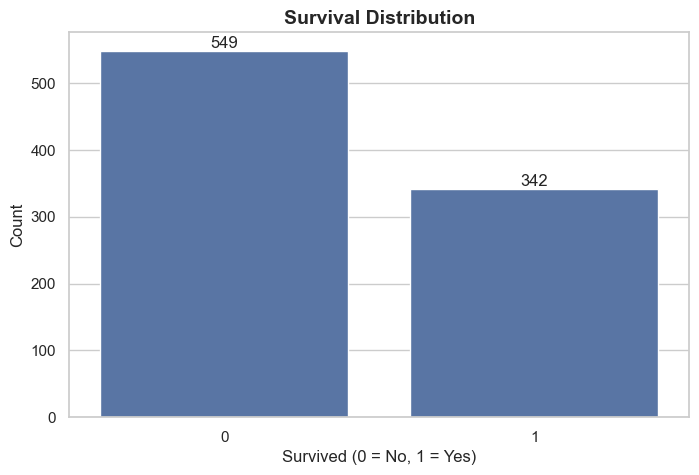

In [6]:
ax = sns.countplot(x='Survived', data=train)

plt.title("Survival Distribution", fontsize=14, weight='bold')
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")

for c in ax.containers:
    ax.bar_label(c)

plt.show()

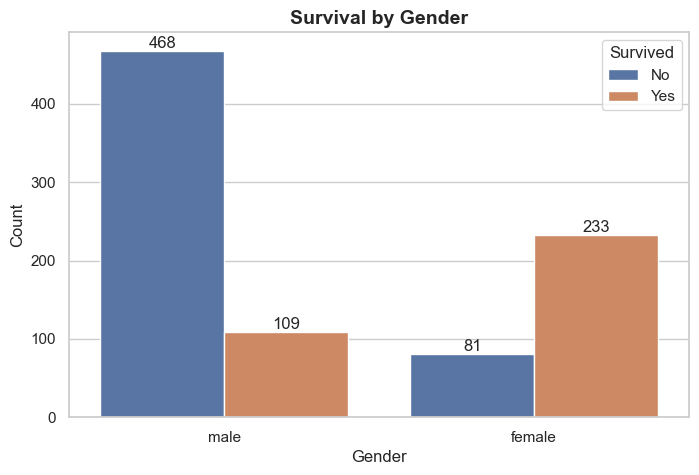

In [7]:
ax = sns.countplot(x='Sex', hue='Survived', data=train)

plt.title("Survival by Gender", fontsize=14, weight='bold')
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Survived", labels=["No", "Yes"])

for c in ax.containers:
    ax.bar_label(c)

plt.show()

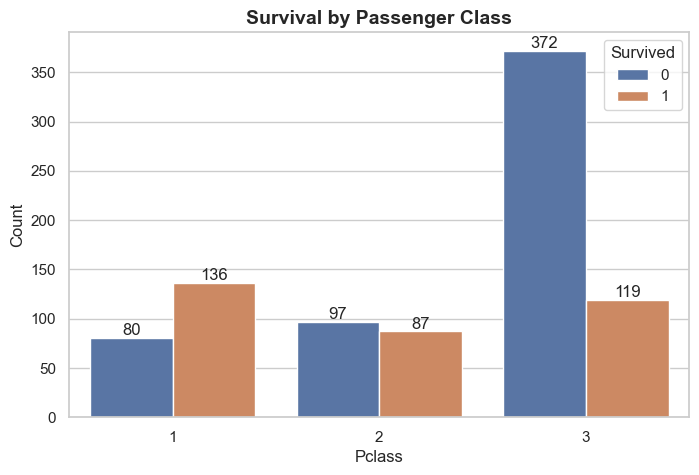

In [8]:
ax = sns.countplot(x='Pclass', hue='Survived', data=train)

plt.title("Survival by Passenger Class", fontsize=14, weight='bold')
plt.xlabel("Pclass")
plt.ylabel("Count")

for c in ax.containers:
    ax.bar_label(c)

plt.show()

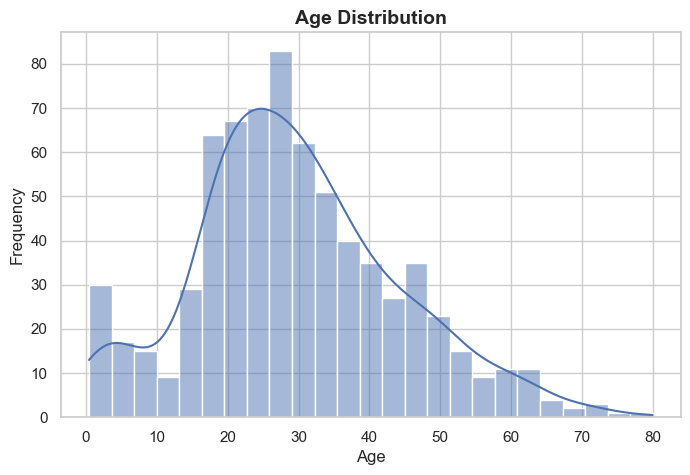

In [9]:
sns.histplot(train['Age'].dropna(), bins=25, kde=True)

plt.title("Age Distribution", fontsize=14, weight='bold')
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

In [10]:
# Observations:
# - Majority of passengers did not survive
# - Females have higher survival rate
# - Higher class passengers survived more
# - Most passengers are between 20–40 years

In [11]:
train['Age'] = train['Age'].fillna(train['Age'].median())

embarked_mode = train['Embarked'].mode()
if not embarked_mode.empty:
    train['Embarked'] = train['Embarked'].fillna(embarked_mode[0])

In [13]:
train = train.drop(['Cabin', 'Name', 'Ticket', 'PassengerId'], axis=1)

In [14]:
train['Sex'] = train['Sex'].map({'male': 0, 'female': 1})

train = pd.get_dummies(train, columns=['Embarked'], drop_first=True)

print("Shape after preprocessing:", train.shape)

Shape after preprocessing: (891, 9)


In [15]:
print(train.isnull().sum())
train.head()

Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
dtype: int64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


In [16]:
from sklearn.model_selection import train_test_split

X = train.drop('Survived', axis=1)
y = train['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (712, 8)
Test shape: (179, 8)


In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [18]:
train_accuracy = model.score(X_train, y_train)

print("\nTraining Accuracy:", round(train_accuracy, 2))


Training Accuracy: 0.8


In [19]:
sample = X_train.iloc[0:1]
prediction = model.predict(sample)

print("\nSample Input:\n", sample)
print("\nPrediction:", "Survived" if prediction[0]==1 else "Not Survived")


Sample Input:
      Pclass  Sex   Age  SibSp  Parch  Fare  Embarked_Q  Embarked_S
331       1    0  45.5      0      0  28.5       False        True

Prediction: Not Survived


In [20]:
print("✅ Model Training Completed")

print("\nIntercept:", model.intercept_)

coeff_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

print("\nTop Features Influencing Survival:\n")
print(coeff_df.sort_values(by='Coefficient', ascending=False).head())

print("\nTraining Accuracy:", round(model.score(X_train, y_train), 2))

sample = X_train.iloc[0:1]
pred = model.predict(sample)

print("\nSample Prediction:", "Survived" if pred[0]==1 else "Not Survived")

✅ Model Training Completed

Intercept: [1.94369736]

Top Features Influencing Survival:

      Feature  Coefficient
1         Sex     2.591383
5        Fare     0.002579
2         Age    -0.030574
4       Parch    -0.108161
6  Embarked_Q    -0.112324

Training Accuracy: 0.8

Sample Prediction: Not Survived


In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.8100558659217877
Precision: 0.7857142857142857
Recall: 0.7432432432432432
F1 Score: 0.7638888888888888


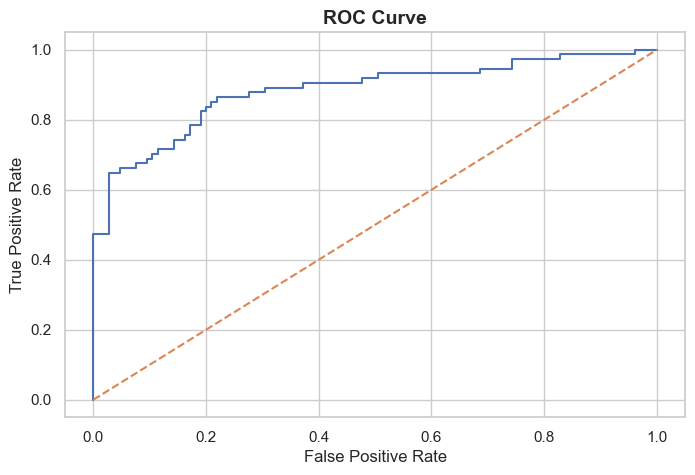

ROC-AUC Score: 0.8824967824967825


In [22]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve", fontsize=14, weight='bold')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

In [23]:
coeff = pd.DataFrame(model.coef_[0], X.columns, columns=['Coefficient'])
coeff.sort_values(by='Coefficient', ascending=False)

,Coefficient
Sex,2.591383
Fare,0.002579
Age,-0.030574
Parch,-0.108161
Embarked_Q,-0.112324
SibSp,-0.295223
Embarked_S,-0.400069
Pclass,-0.938010


In [26]:
# Interpretation:
# - Positive coefficient increases survival probability
# - Female gender strongly increases survival chances
# - Higher class passengers are more likely to survive

In [27]:
import pickle
pickle.dump(model, open("model.pkl", "wb"))

In [28]:
# 1. Precision vs Recall:
# Precision → correct predicted positives
# Recall → actual positives identified

# 2. Cross Validation:
# Technique to split data into multiple folds for reliable model performance